# Major Data Analytics Project
## Seasonal Agriculture Performance Analysis

**Domain:** Agriculture  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

> **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required.

This notebook follows the project requirements in the supplied project brief: dataset understanding, cleaning, descriptive/statistical analysis, univariate/bivariate/multivariate analysis, correlation, seasonal comparison, student-designed analyses, insights, conclusions, recommendations and limitations.

## 1. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

## 2. Objectives
- Explore and understand the dataset.
- Clean and prepare the data.
- Examine agricultural performance across seasons.
- Identify seasonal patterns and trends.
- Investigate relationships between conditions and outcomes.
- Compare relevant groups across seasons.
- Identify significant/unusual patterns.
- Apply statistical and visualization techniques.
- Interpret evidence and develop data-driven recommendations.

## 3. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 4. Load Dataset

In [ ]:
import os
file_name = "seasonal_agriculture_performance_dataset.csv"
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
else:
    # Google Colab fallback
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(next(iter(uploaded)))

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Dataset loaded successfully.
Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 5. Dataset Shape and Structure

In [ ]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (4000, 28)

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          fl

## 6. Top 5 Rows, Last 5 Rows and Random Sample

In [ ]:
print("Top 5 rows")
display(df.head())
print("Last 5 rows")
display(df.tail())
print("Random sample (random_state=42)")
display(df.sample(5, random_state=42))

Top 5 rows


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


Last 5 rows


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


Random sample (random_state=42)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


## 7. Descriptive Statistics

In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 8. Categorical Summary

In [ ]:
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"\n{col}:")
    print(df[col].value_counts())


State:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


## 9. Missing Values

In [ ]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"Missing_Count": missing, "Missing_Percent": missing_pct})
display(missing_table[missing_table.Missing_Count > 0])

,Missing_Count,Missing_Percent
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


### Missing-value treatment
Only a small number of values are missing in `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha`. Since these are numeric measurements, median imputation is used to reduce the effect of extreme values.

In [ ]:
numeric_impute = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]
for col in numeric_impute:
    df[col] = df[col].fillna(df[col].median())
print("Missing values after treatment:", int(df.isna().sum().sum()))

Missing values after treatment: 0


## 10. Duplicate Records

In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate records:", duplicate_count)
if duplicate_count:
    df = df.drop_duplicates().copy()
    print("Shape after removing duplicates:", df.shape)

Duplicate records: 0


## 11. Outlier Investigation (IQR Method)

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
outlier_summary = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, count, lower, upper])
outliers = pd.DataFrame(outlier_summary, columns=["Variable","Outlier_Count","Lower_Bound","Upper_Bound"]).sort_values("Outlier_Count", ascending=False)
display(outliers.head(15))

,Variable,Outlier_Count,Lower_Bound,Upper_Bound
18,Profit_INR,404,"-696,111.00","763,567.00"
14,Production_Tonnes,333,-23.98,53.36
20,Water_Efficiency_t_per_1000m3,322,-3.57,10.38
13,Yield_Tonnes_Ha,302,-1.62,5.50
19,Water_Used_m3,276,"-6,072.75","16,171.25"
17,Revenue_INR,240,"-736,519.00","1,780,911.00"
9,Potassium_kg_ha,32,30.10,179.70
4,Sunlight_Hours_Day,26,4.35,10.35
8,Phosphorus_kg_ha,16,11.40,104.20
10,Fertilizer_kg_ha,15,19.14,352.04


## 12. Univariate Analysis
### Season Distribution

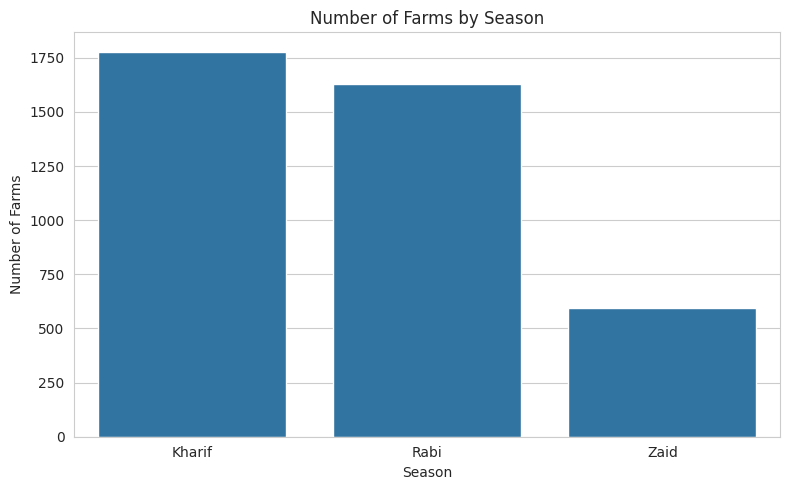

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Season", color="C0")
plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.tight_layout(); plt.show()

### Profit Distribution

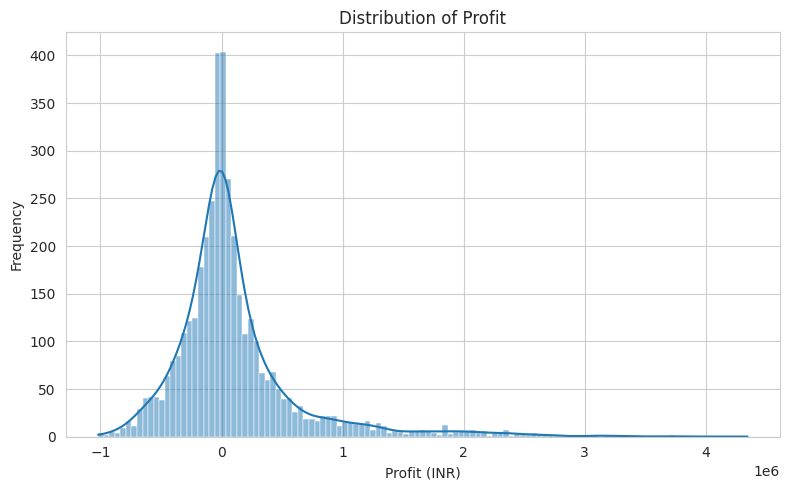

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Profit_INR", kde=True, color="C0")
plt.title("Distribution of Profit")
plt.xlabel("Profit (INR)"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()

### Rainfall Distribution

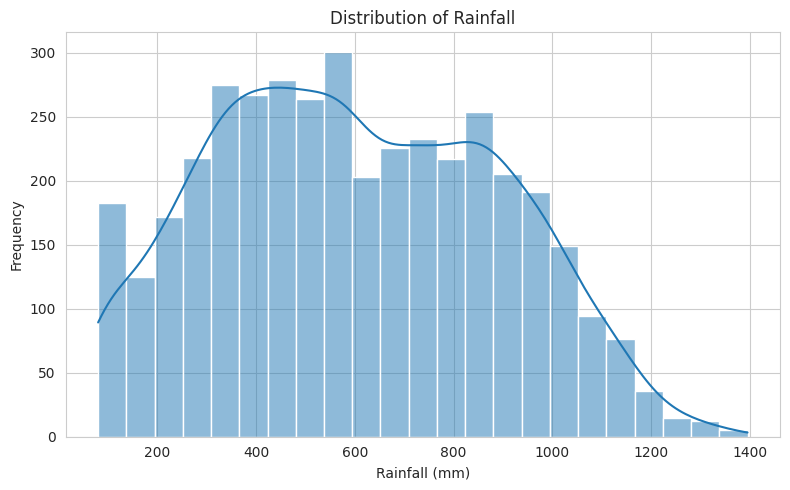

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Rainfall_mm", kde=True, color="C0")
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()

### Yield Distribution

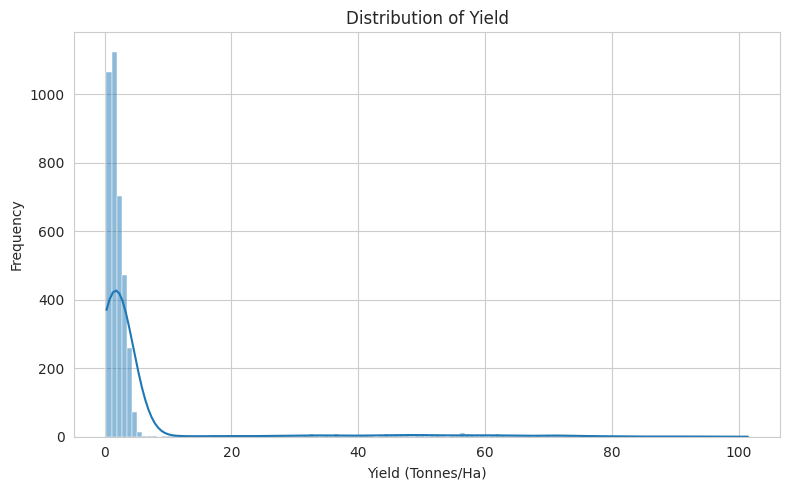

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True, color="C0")
plt.title("Distribution of Yield")
plt.xlabel("Yield (Tonnes/Ha)"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()

## 13. Bivariate Analysis
### Season vs Average Yield

Season
Kharif   5.63
Rabi     5.04
Zaid     4.64
Name: Yield_Tonnes_Ha, dtype: float64


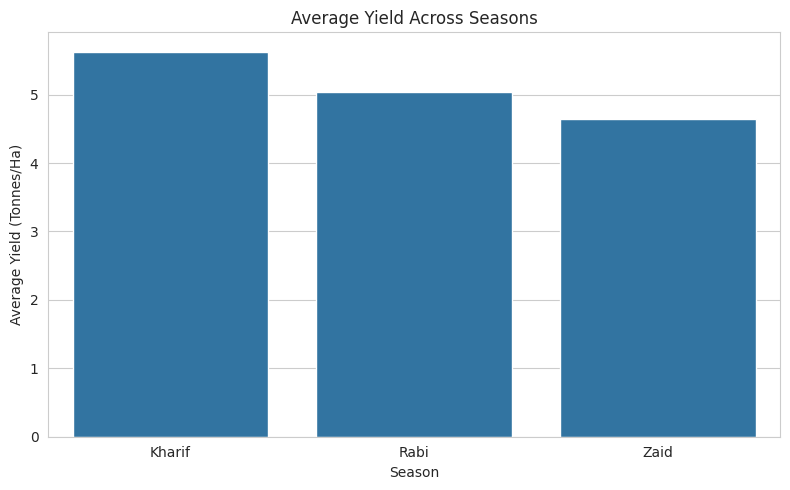

In [ ]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)
print(season_yield.round(2))
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", estimator="mean", errorbar=None, color="C0")
plt.title("Average Yield Across Seasons")
plt.xlabel("Season"); plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout(); plt.show()

### Season vs Profit

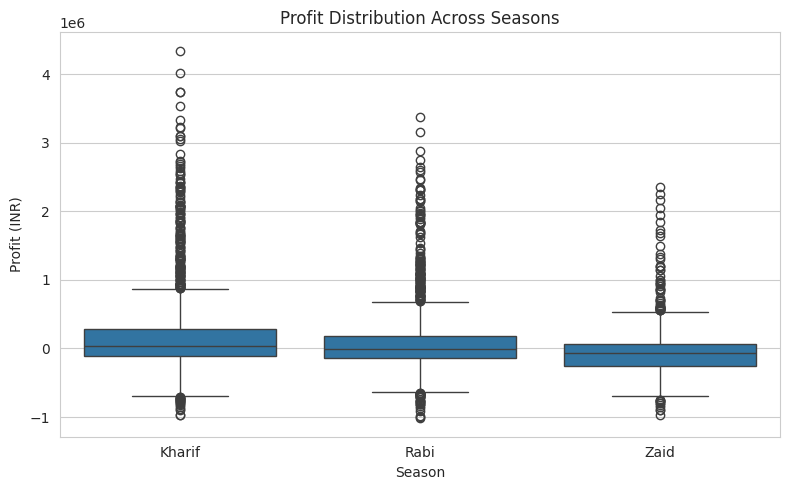

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Season", y="Profit_INR", color="C0")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season"); plt.ylabel("Profit (INR)")
plt.tight_layout(); plt.show()

### Season vs Rainfall

In [ ]:
season_weather = df.groupby("Season")[["Rainfall_mm","Avg_Temperature_C","Humidity_pct","Sunlight_Hours_Day"]].mean().round(2)
display(season_weather)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,849.20,28.45,71.81,6.79
Rabi,437.62,23.49,57.89,7.59
Zaid,304.65,31.04,52.01,8.18


## 14. Seasonal Performance Comparison

In [ ]:
season_summary = df.groupby("Season").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha","mean"),
    Avg_Production_Tonnes=("Production_Tonnes","mean"),
    Avg_Revenue_INR=("Revenue_INR","mean"),
    Avg_Cost_INR=("Total_Cost_INR","mean"),
    Avg_Profit_INR=("Profit_INR","mean"),
    Avg_Water_Used_m3=("Water_Used_m3","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Avg_Disease_Pest_Risk=("Disease_Pest_Risk_pct","mean")
).round(2)
season_summary["Profit_Positive_%"] = df.groupby("Season")["Profit_INR"].apply(lambda s: (s>0).mean()*100).round(2)
display(season_summary)

,Farms,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk,Profit_Positive_%
Season,,,,,,,,,,
Kharif,1779,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47,57.79
Rabi,1627,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48,48.86
Zaid,594,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22,35.52


Additional Analytical Questions and Findings
## 15. Which crop performs best in terms of yield and profit?: Crop Performance

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
Crop,,,,
Sugarcane,305,46.64,"817,187.99",30.48
Chilli,412,1.54,"750,878.34",2.95
Cotton,508,1.23,"124,546.92",1.94
Groundnut,424,1.32,"44,858.12",3.15
Pulses,496,0.92,"-4,238.05",2.90
Maize,551,2.71,"-83,978.33",5.60
Rice,690,2.43,"-102,213.50",1.95
Wheat,614,2.11,"-123,398.34",4.63


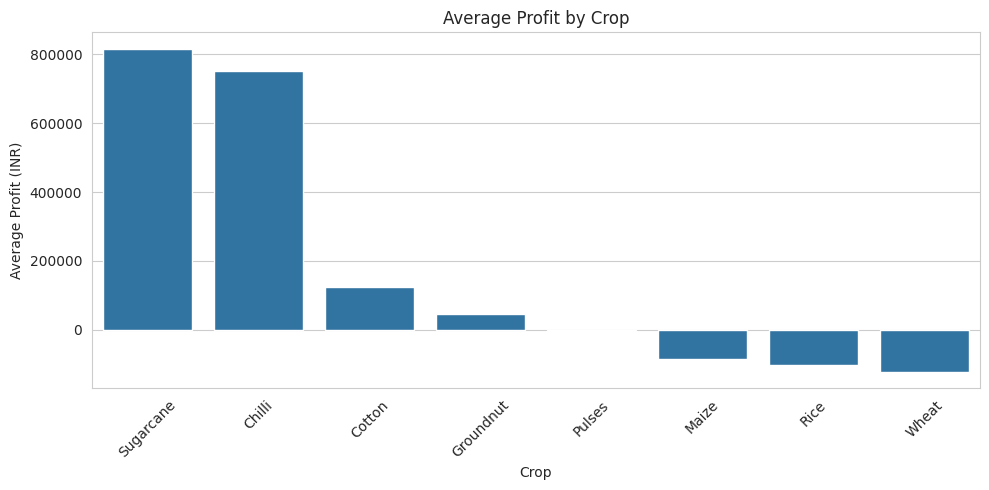

In [ ]:
crop_summary = df.groupby("Crop").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
).sort_values("Avg_Profit", ascending=False).round(2)
display(crop_summary)

plt.figure(figsize=(10,5))
sns.barplot(x=crop_summary.index, y=crop_summary["Avg_Profit"].values, errorbar=None, color="C0")
plt.xticks(rotation=45); plt.title("Average Profit by Crop"); plt.xlabel("Crop"); plt.ylabel("Average Profit (INR)")
plt.tight_layout(); plt.show()

Additional Analytical Questions and Findings
## 16. How does irrigation method affect agricultural performance and water efficiency?: Irrigation Method Performance

In [ ]:
irrigation_summary = df.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Avg_Water_Used=("Water_Used_m3","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
).sort_values("Avg_Profit", ascending=False).round(2)
display(irrigation_summary)

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.58,"219,626.00","5,918.75",6.27
Sprinkler,734,5.16,"91,121.08","6,208.26",4.67
Rainfed,1041,4.60,"79,050.37","3,549.55",7.56
Flood,1310,4.86,"73,354.02","8,026.47",3.44


Additional Analytical Questions and Findings
## 17. How does crop performance vary across different seasons?: Crop × Season Comparison

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"954,380.42","638,572.50","448,659.09"
Cotton,"216,999.55","107,343.59","-53,925.34"
Groundnut,"108,265.44","10,416.54","-68,872.50"
Maize,"-39,332.67","-89,133.40","-194,049.17"
Pulses,"43,338.90","-14,309.14","-139,227.81"
Rice,"-64,903.40","-98,427.87","-227,239.34"
Sugarcane,"1,000,790.81","731,612.86","583,635.80"
Wheat,"-105,871.87","-119,954.57","-193,208.95"


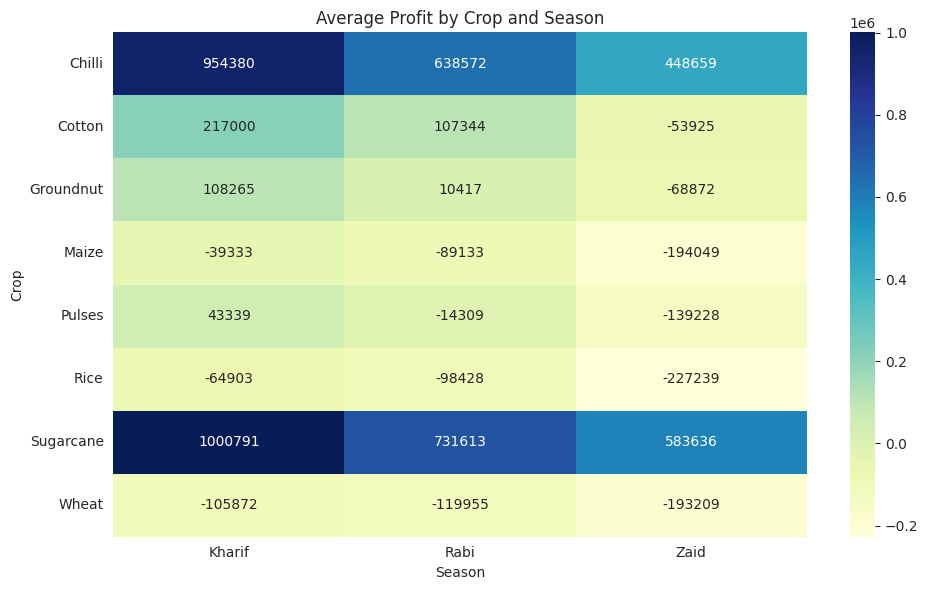

In [ ]:
crop_season = pd.pivot_table(df, index="Crop", columns="Season", values="Profit_INR", aggfunc="mean")
display(crop_season.round(2))
plt.figure(figsize=(10,6))
sns.heatmap(crop_season, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Profit by Crop and Season")
plt.xlabel("Season"); plt.ylabel("Crop")
plt.tight_layout(); plt.show()

## 18. Multivariate Analysis: Season × Irrigation × Yield

Yield_Tonnes_Ha  Profit_INR  \
Season Irrigation_Method                                
Kharif Drip                          7.26  317,222.07   
       Flood                         4.98  133,373.83   
       Rainfed                       5.70  158,974.13   
       Sprinkler                     4.66  116,880.49   
Rabi   Drip                          6.11  187,843.22   
       Flood                         5.06   58,824.80   
       Rainfed                       3.93   45,232.48   
       Sprinkler                     5.31   76,502.07   
Zaid   Drip                          5.85   21,291.84   
       Flood                         3.98  -69,786.78   
       Rainfed                       3.06  -79,467.26   
       Sprinkler                     6.14   57,909.40   

                          Water_Efficiency_t_per_1000m3  
Season Irrigation_Method                                 
Kharif Drip                                        6.80  
       Flood                                       3.64  
       Rainfed                                     8.85  
       Sprinkler                                   4.62  
Rabi   Drip                                        6.05  
       Flood                                       3.48  
       Rainfed                                     6.87  
       Sprinkler                                   4.64  
Zaid   Drip                                        5.30  
       Flood                                       2.73  
       Rainfed                                     5.48  
       Sprinkler                                   4.86

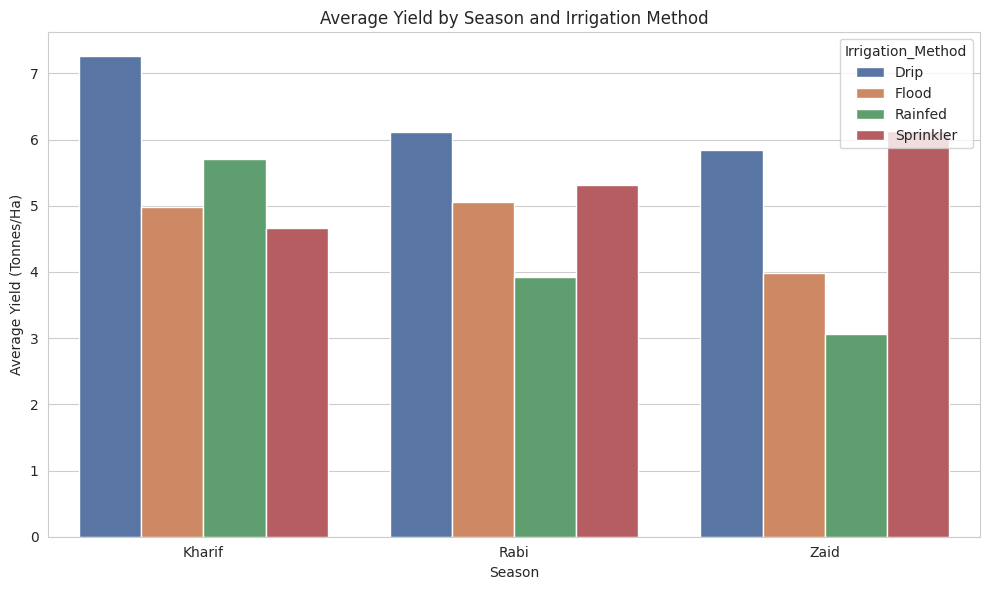

In [ ]:
multi = df.groupby(["Season","Irrigation_Method"])[["Yield_Tonnes_Ha","Profit_INR","Water_Efficiency_t_per_1000m3"]].mean().round(2)
display(multi)

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", hue="Irrigation_Method", estimator="mean", errorbar=None, palette="deep")
plt.title("Average Yield by Season and Irrigation Method")
plt.xlabel("Season"); plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout(); plt.show()

## 19. Correlation Analysis

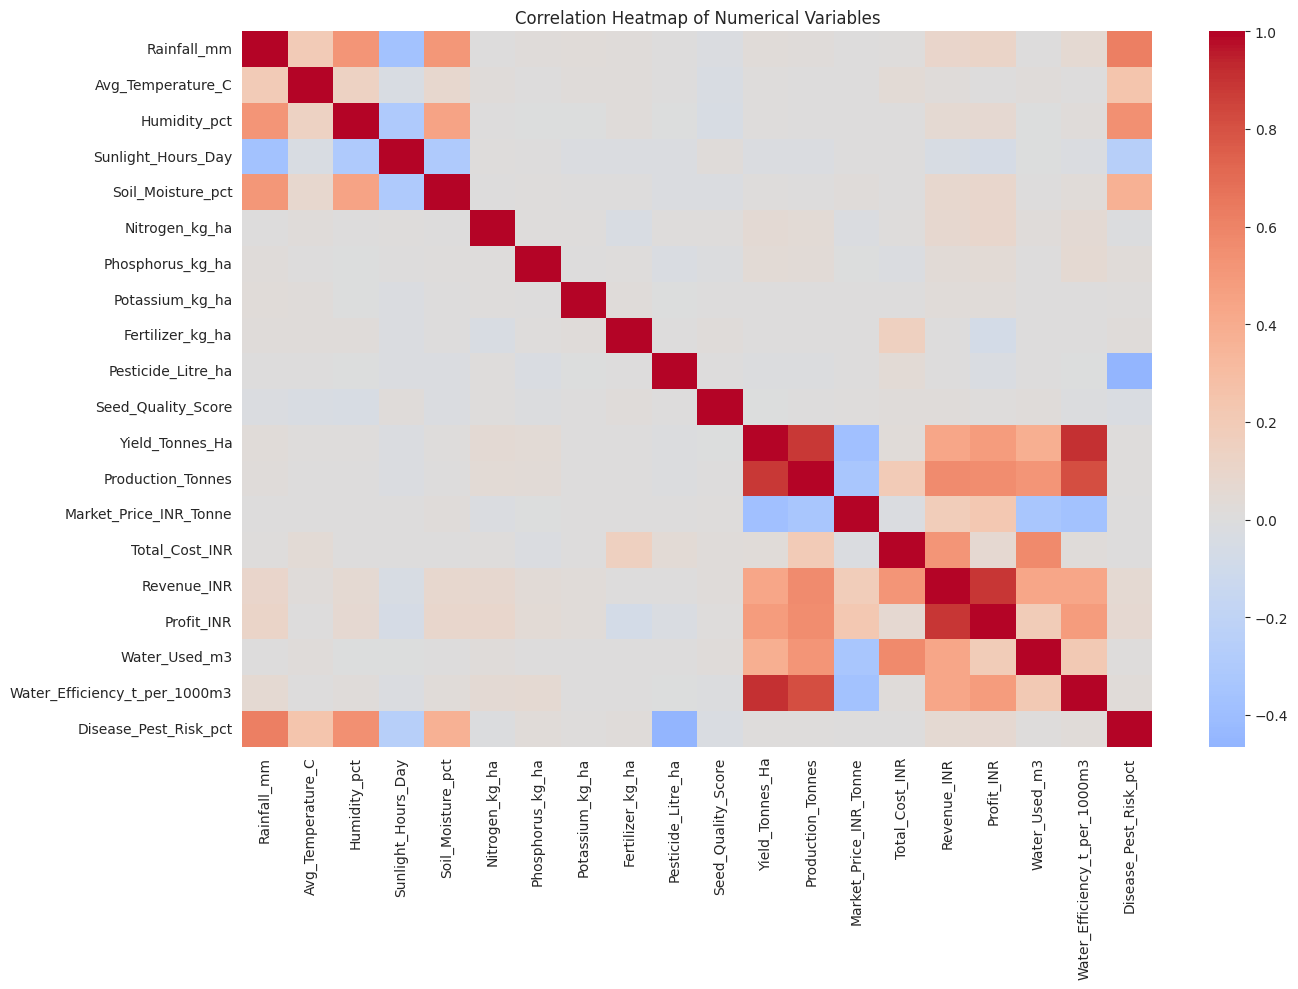


Variables most positively correlated with Profit:


,Correlation
Profit_INR,1.00
Revenue_INR,0.89
Production_Tonnes,0.55
Water_Efficiency_t_per_1000m3,0.49
Yield_Tonnes_Ha,0.49
Market_Price_INR_Tonne,0.23
Water_Used_m3,0.19
Rainfall_mm,0.11
Soil_Moisture_pct,0.09
Nitrogen_kg_ha,0.09


In [ ]:
corr_cols = ["Rainfall_mm","Avg_Temperature_C","Humidity_pct","Sunlight_Hours_Day","Soil_Moisture_pct","Nitrogen_kg_ha","Phosphorus_kg_ha","Potassium_kg_ha","Fertilizer_kg_ha","Pesticide_Litre_ha","Seed_Quality_Score","Yield_Tonnes_Ha","Production_Tonnes","Market_Price_INR_Tonne","Total_Cost_INR","Revenue_INR","Profit_INR","Water_Used_m3","Water_Efficiency_t_per_1000m3","Disease_Pest_Risk_pct"]
corr = df[corr_cols].corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout(); plt.show()
print("\nVariables most positively correlated with Profit:")
display(corr["Profit_INR"].sort_values(ascending=False).head(10).to_frame("Correlation"))

## 20. Statistical Tests
### One-way ANOVA: Does mean yield differ by season?

ANOVA is used to test whether the average yield is statistically different across the three seasons.

In [ ]:
groups = [g["Yield_Tonnes_Ha"].dropna().values for _, g in df.groupby("Season")]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA F-statistic = {f_stat:.4f}")
print(f"p-value = {p_value:.6g}")
print("Conclusion:", "Statistically significant difference in mean yield across seasons (p < 0.05)." if p_value < 0.05 else "No statistically significant difference in mean yield across seasons (p >= 0.05).")

ANOVA F-statistic = 1.5439
p-value = 0.213678
Conclusion: No statistically significant difference in mean yield across seasons (p >= 0.05).


## 21. Additional Relationship Analysis: Rainfall vs Yield

Pearson correlation between rainfall and yield: r = 0.0310, p = 0.050304


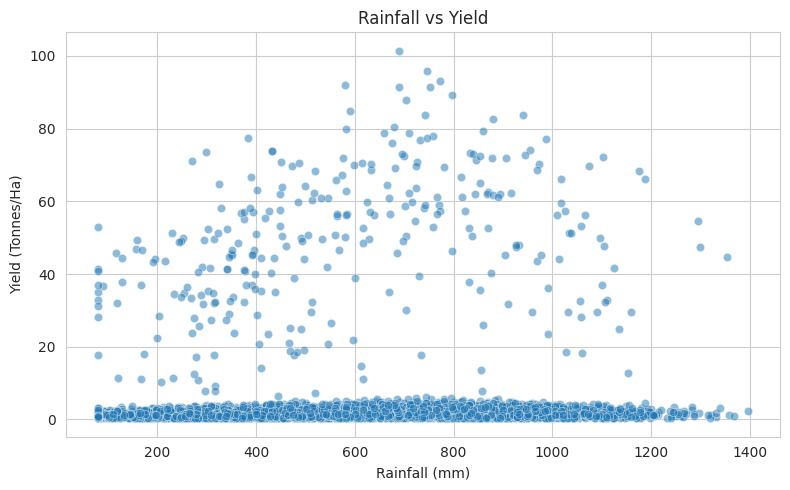

In [ ]:
r, p = stats.pearsonr(df["Rainfall_mm"], df["Yield_Tonnes_Ha"])
print(f"Pearson correlation between rainfall and yield: r = {r:.4f}, p = {p:.6g}")

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5, color="C0")
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)"); plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout(); plt.show()

## 22. Key Results / Findings
The following results are calculated directly from the supplied dataset after the documented median treatment of missing numeric values.

In [ ]:
# Compact results for reporting
results = {
    "Total records": len(df),
    "Total variables": df.shape[1],
    "Seasons": ", ".join(df["Season"].unique()),
    "Highest average yield season": season_summary["Avg_Yield_Tonnes_Ha"].idxmax(),
    "Highest average profit season": season_summary["Avg_Profit_INR"].idxmax(),
    "Highest positive-profit share": season_summary["Profit_Positive_%"].idxmax(),
    "Highest average profit crop": crop_summary["Avg_Profit"].idxmax(),
    "Highest average yield irrigation method": irrigation_summary["Avg_Yield"].idxmax(),
    "Highest water efficiency irrigation method": irrigation_summary["Avg_Water_Efficiency"].idxmax(),
}
for k,v in results.items(): print(f"{k}: {v}")
print("\nSeason summary:"); display(season_summary)

Total records: 4000
Total variables: 28
Seasons: Kharif, Rabi, Zaid
Highest average yield season: Kharif
Highest average profit season: Kharif
Highest positive-profit share: Kharif
Highest average profit crop: Sugarcane
Highest average yield irrigation method: Drip
Highest water efficiency irrigation method: Rainfed

Season summary:


,Farms,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk,Profit_Positive_%
Season,,,,,,,,,,
Kharif,1779,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47,57.79
Rabi,1627,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48,48.86
Zaid,594,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22,35.52


## 23. At Least 8 Meaningful Insights
1. **Kharif is the strongest season overall:** it has the highest average yield, revenue, profit and water efficiency among the three seasons.
2. **Zaid is financially weakest on average:** its mean profit is negative, while Kharif and Rabi have positive mean profit.
3. **Profitability is highly variable:** the profit distribution is strongly spread and contains both large losses and large gains, so mean profit should be interpreted together with the median and distribution.
4. **Kharif has the highest positive-profit rate:** more farms are profitable in Kharif than in Rabi or Zaid.
5. **Sugarcane stands out by crop:** it has by far the highest average yield, profit and water-efficiency values in this dataset.
6. **Drip irrigation performs strongly for yield and profit:** among irrigation methods, Drip has the highest average yield and average profit.
7. **Rainfed irrigation has the highest water efficiency:** it uses the least water on average and has the highest tonnes-per-1000m³ efficiency, although this does not make it the most profitable method.
8. **Revenue is the strongest direct numerical driver of profit:** profit has a very strong positive correlation with revenue; production and yield also show positive relationships with profit.
9. **Yield is strongly associated with water efficiency and production:** these variables have strong positive correlations with yield, indicating that output and resource efficiency move together in the observed data.
10. **Seasonal environmental conditions differ clearly:** Kharif has much higher average rainfall and disease/pest risk than Rabi and Zaid, showing that seasonal conditions are an important part of interpreting performance.
11. **Crop-season combinations are not uniform:** the heatmap shows that the profitability of a crop changes by season, so crop choice should not be evaluated independently of season.
12. **Outliers matter:** several financial and production variables contain extreme observations, so medians, boxplots and IQR-based outlier checks are important when interpreting averages.

## 24. Conclusions
The analysis shows clear seasonal variation in agricultural performance. Kharif generally performs best on yield, profitability and water efficiency, while Zaid shows weaker average financial performance. Crop choice and irrigation method also have substantial differences. The correlation and statistical analyses indicate meaningful relationships among yield, production, water efficiency and economic outcomes. These findings support the project goal of using evidence from agricultural data for better seasonal planning.

## 25. Data-Driven Recommendations
- Give priority to crops and farming practices that show strong profitability in the target season.
- Consider efficient irrigation methods such as Drip where appropriate, while balancing water availability and cost.
- Use seasonal rainfall, temperature and disease/pest conditions when planning crops.
- Do not rely only on average profit; inspect median values and extreme observations before making decisions.
- Compare crop performance within each season rather than assuming one crop is best in every season.
- Monitor water efficiency together with yield and profitability to balance production and resource use.
- Investigate the causes of large losses and unusually high profits as potential areas for further study.
- Use the results as analytical evidence rather than as universal agricultural rules, because the dataset represents the observed records only.

## 26. Limitations
- The dataset is observational and does not by itself prove causal relationships.
- Missing numeric values were imputed using medians, which can slightly affect distributions.
- Extreme values are present and can strongly influence means.
- The analysis is limited to the variables and records provided in the dataset.
- Seasonal results may not generalize to all farms or regions outside the dataset.
- Statistical associations should not be interpreted as proof that one factor directly causes another.

## 27. Project Checklist
- [x] Dataset loaded successfully
- [x] Top 5 rows analyzed
- [x] Dataset shape and structure examined
- [x] Data types examined
- [x] Missing values identified and handled
- [x] Duplicate records identified and handled
- [x] Descriptive/statistical analysis performed
- [x] Outliers investigated
- [x] Univariate analysis completed
- [x] Bivariate analysis completed
- [x] Multivariate analysis completed
- [x] Correlation analysis completed
- [x] Seasonal comparisons performed
- [x] Additional Analytical Questions and Findings
- [x] At least 8 meaningful insights documented
- [x] Conclusions and recommendations provided
- [x] Limitations discussed
- [x] Complete analysis documented in Google Collab